In [82]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd


In [95]:
# várias coisas do scikit-learn
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier # conta a classe popular, todos os novos vão para classe pop

In [63]:
mnist = fetch_openml('mnist_784',as_frame=True)

In [36]:
mnist.target

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [40]:
#Processo de Reshape: Transformar as linhas do dataframe em matrizes novamente
#Vamos utilizar o Numpy, que é a ferramenta padrão para trabalhar com matrizes no python

primeiro_digito_achatado = mnist.data.iloc[0].to_numpy()
primeiro_digito_achatado

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [41]:
# 2. Fazemos o "Reshape" para 28x28
# O comando diz: "pegue esses 784 números e organize em 28 linhas e 28 colunas"
imagem_2d = primeiro_digito_achatado.reshape(28, 28)
imagem_2d

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

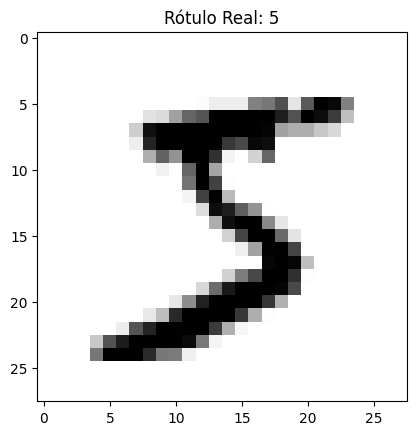

In [42]:
# 3. Agora podemos visualizar o "mosaico" completo
plt.imshow(imagem_2d, cmap="binary")
plt.title(f"Rótulo Real: {mnist.target.iloc[0]}")
#plt.axis("off") # Esconde as réguas laterais
plt.show()

In [64]:
X,y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


<function matplotlib.pyplot.show(close=None, block=None)>

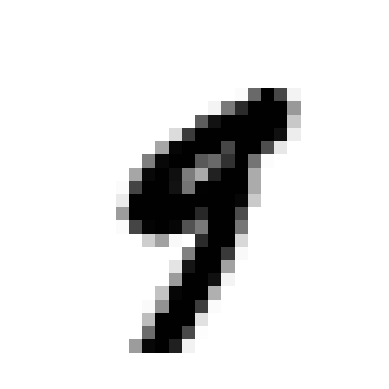

In [ ]:
%matplotlib inline

some_digit = X[36000]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show

In [84]:
y = pd.DataFrame(y)

In [85]:
X_train, X_test = X.iloc[:60_000,:], X.iloc[60_000:,:]
y_train, y_test =  y.iloc[:60_000,:].astype(np.int64), y.iloc[60_000:,:].astype(np.int64)


In [86]:
shuffle_index = np.random.permutation(60000)
X_train, y_train = X_train.iloc[shuffle_index], y_train.iloc[shuffle_index]

In [87]:
y_train_5 = y_train == 5 # True for all 5s, False for all other digits
y_test_5 = y_test == 5

print(np.unique(y_train_5))

[False  True]


In [ ]:
sgd_clf =   SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

In [92]:
some_digit = X.iloc[0, :].to_numpy()


In [93]:
some_digit.shape

(784,)

In [94]:
sgd_clf.predict(some_digit.reshape(1, 784))

/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [96]:
acuracias = cross_val_score(sgd_clf, X_train, y_train_5, scoring='accuracy', cv=3)

/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/psyche/.pyenv/versions/3.10.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [97]:
acuracias

array([0.9561 , 0.96305, 0.91895])

In [98]:
zero_r = DummyClassifier()
zero_r.fit(X_train, y_train_5)

,strategy,'prior'
,random_state,None
,constant,None


In [99]:
acuracias_zero_r = cross_val_score(zero_r, X_train, y_train_5, scoring='accuracy', cv=3)

In [100]:
acuracias_zero_r

array([0.90965, 0.90965, 0.90965])